Adapted from decoupler tutorial "Pseudobulk Enrichment Analysis":

https://decoupler.readthedocs.io/en/latest/notebooks/scell/rna_psbk.html

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import decoupler as dc

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

import math
import os
import tqdm

import itertools
import functools

os.environ['R_HOME'] = '/home/trc891/.conda/envs/cfn_final/lib/R'

import rpy2.robjects as ro
from rpy2.robjects import pandas2ri, Formula, StrVector
pandas2ri.activate()
from rpy2.robjects.packages import importr
from rpy2.rinterface_lib.embedded import RRuntimeError

deseq = importr('DESeq2')

/home/trc891/.conda/envs/cfn_final/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/trc891/.conda/envs/cfn_final/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/trc891/.conda/envs/cfn_final/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/trc891/.conda/envs/cfn_final/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/trc891/.conda/envs/cfn_final/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Impor

In [2]:
dc.__version__

'2.1.1'

In [24]:
DATA_DIR = '../data/cfhv_sc'
OUTPUT_DIR = '../data/figs/cfhv_sc'

#SAMPLE_SHEET_PATH = f'{DATA_DIR}/CF_samples_2022_08_16_1000hvg.csv'
#sample_sheet = pd.read_csv(SAMPLE_SHEET_PATH)

ds = sc.read_h5ad(f'{DATA_DIR}/cfhv_sc_obj.h5ad')

#sample_sheet.sort_values('Class', ascending=False, inplace=True)

In [4]:
cluster_kw = 'cell_type_annot'

subj_ids = ds.obs['Sample'].unique()
clusters = ds.obs[cluster_kw].unique()

In [5]:
ds.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 6299462 stored elements and shape (89601, 1000)>

In [6]:
ds.raw.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 101232911 stored elements and shape (89601, 22039)>

In [7]:
ds.obs.columns

Index(['orig.ident', 'Doublet score', 'Library ID', 'Chemistry', 'Class',
       'Cell viabiliy', 'Sex', 'OnModulator', 'n_genes', 'batch',
       'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_10_genes',
       'pct_counts_in_top_20_genes', 'total_counts_mito', 'pct_counts_mito',
       'total_counts_ribo', 'pct_counts_ribo', '_scvi_batch', '_scvi_labels',
       'leiden', 'Sample', 'leiden_mod', 'leiden_unmerged', 'leiden_final',
       'cell_type_annot', 'cell_type_annot_unmerged', 'leiden_orig'],
      dtype='object')

In [8]:
MIN_CELLS_PER_CLUSTER = 10

psct_list = []
n_genes = ds.raw.X.shape[1]
n_clusters = len(clusters)

for subj_id in tqdm.tqdm(subj_ids):
    ct_mat = np.zeros((n_clusters, n_genes)) # we assume ds.raw.X is count data, unscaled
    n_cells = []

    for i, c in enumerate(clusters):
        cl_ds = ds[(ds.obs['Sample'] == subj_id) & (ds.obs[cluster_kw] == c)]
        pseudocounts = cl_ds.raw.X.sum(axis=0).A
        ct_mat[i,:] = pseudocounts
        n_cells.append(cl_ds.shape[0])

    subj_ds = pd.DataFrame(ct_mat, columns=cl_ds.raw.var.index)
    subj_ds.insert(0, 'n_cells', n_cells)
    subj_ds.insert(0, cluster_kw, clusters)
    subj_ds.insert(0, 'OnModulator', [ds[ds.obs['Sample'] == subj_id].obs['OnModulator'].iloc[0]] * len(clusters))
    subj_ds.insert(0, 'Class', [ds[ds.obs['Sample'] == subj_id].obs['Class'].iloc[0]] * len(clusters))
    subj_ds.insert(0, 'Sex', [ds[ds.obs['Sample'] == subj_id].obs['Sex'].iloc[0]] * len(clusters))
    subj_ds.insert(0, 'Sample', [ds[ds.obs['Sample'] == subj_id].obs['Sample'].iloc[0]] * len(clusters))
    
    new_index = list(subj_ds[['Sample', cluster_kw]].agg('_'.join, axis=1))
    subj_ds.insert(0, 'idx', new_index)
    subj_ds = subj_ds.set_index('idx')

    psct_list.append(subj_ds)
    
psct_df = pd.concat(psct_list)
psct_df.sort_values('Class', ascending=False, inplace=True) # Put NC values first so they are used as DESeq2 controls


# count filters

col_filt = [c for c in psct_df.columns[6:] if ((psct_df[c] > 50).sum() > 5)] # filter genes that don't have x samples with y counts
# col_filt = [c for c in psct_df.columns[6:] if (psct_df[c].sum() > 100)] # filter genes that don't have more than 50 reads
psct_df_filt_genes = psct_df[psct_df.columns[:6].tolist() + col_filt]

psct_df_filt_genes = psct_df_filt_genes[psct_df_filt_genes['n_cells'] > MIN_CELLS_PER_CLUSTER]

100%|██████████| 16/16 [00:06<00:00,  2.55it/s]


In [9]:
psct_df

,Sample,Sex,Class,OnModulator,cell_type_annot,n_cells,A1BG,A1BG-AS1,A2M,A2M-AS1,...,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1
idx,,,,,,,,,,,,,,,,,,,,,
CFHV_sc_subj_050_pDCs,CFHV_sc_subj_050,F,HV,NaN,pDCs,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CFHV_sc_subj_051_CD8+ T-cells,CFHV_sc_subj_051,M,HV,NaN,CD8+ T-cells,174,12.0,0.0,0.0,0.0,...,0.0,2.0,0.0,0.0,2.0,2.0,0.0,4.0,37.0,4.0
CFHV_sc_subj_051_CD4+ T-cells,CFHV_sc_subj_051,M,HV,NaN,CD4+ T-cells,75,5.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,9.0,5.0
CFHV_sc_subj_051_B-cells,CFHV_sc_subj_051,M,HV,NaN,B-cells,10,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CFHV_sc_subj_051_pDCs,CFHV_sc_subj_051,M,HV,NaN,pDCs,11,3.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CFHV_sc_subj_013_Macrophages,CFHV_sc_subj_013,F,CF,No,Macrophages,14,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CFHV_sc_subj_013_CD8+ T-cells,CFHV_sc_subj_013,F,CF,No,CD8+ T-cells,9,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CFHV_sc_subj_013_Ionocytes,CFHV_sc_subj_013,F,CF,No,Ionocytes,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
psct_df_filt_genes

,Sample,Sex,Class,OnModulator,cell_type_annot,n_cells,A2ML1,A4GALT,AAAS,AACS,...,ZSWIM8,ZSWIM9,ZUP1,ZW10,ZWILCH,ZWINT,ZXDC,ZYG11B,ZYX,ZZEF1
idx,,,,,,,,,,,,,,,,,,,,,
CFHV_sc_subj_051_CD8+ T-cells,CFHV_sc_subj_051,M,HV,NaN,CD8+ T-cells,174,0.0,3.0,8.0,0.0,...,1.0,0.0,0.0,0.0,2.0,0.0,2.0,4.0,37.0,4.0
CFHV_sc_subj_051_CD4+ T-cells,CFHV_sc_subj_051,M,HV,NaN,CD4+ T-cells,75,0.0,2.0,2.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,4.0,0.0,9.0,5.0
CFHV_sc_subj_051_pDCs,CFHV_sc_subj_051,M,HV,NaN,pDCs,11,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,0.0
CFHV_sc_subj_046_Secretory,CFHV_sc_subj_046,M,HV,NaN,Secretory,669,70.0,1090.0,52.0,41.0,...,93.0,17.0,23.0,43.0,13.0,10.0,74.0,95.0,299.0,144.0
CFHV_sc_subj_046_Multiciliated,CFHV_sc_subj_046,M,HV,NaN,Multiciliated,92,0.0,17.0,9.0,11.0,...,10.0,2.0,2.0,7.0,0.0,2.0,5.0,7.0,2.0,19.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CFHV_sc_subj_013_Monocytes,CFHV_sc_subj_013,F,CF,No,Monocytes,11,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0
CFHV_sc_subj_013_Basal,CFHV_sc_subj_013,F,CF,No,Basal,389,36.0,192.0,20.0,27.0,...,32.0,7.0,10.0,9.0,9.0,21.0,31.0,34.0,111.0,44.0
CFHV_sc_subj_013_Squamous,CFHV_sc_subj_013,F,CF,No,Squamous,96,14.0,34.0,0.0,6.0,...,8.0,7.0,3.0,2.0,4.0,1.0,6.0,2.0,44.0,17.0


In [11]:
DEG_output = {}
CELL_CUTOFF = 0

df = psct_df_filt_genes

for clust_id in clusters:
    filt_psct_df = df[(df['n_cells'] > CELL_CUTOFF) & (df[cluster_kw] == clust_id)]

    n_subj = psct_df[psct_df[cluster_kw] == clust_id].shape[0]
    print(f'cluster {clust_id}: {filt_psct_df.shape[0]} / {n_subj} subjects left after filtering')
    
    des_columns = filt_psct_df.iloc[:, :3]
    print(des_columns)
    
    n_cf = np.sum(des_columns['Class'] == 'CF')
    n_nc = np.sum(des_columns['Class'] == 'HV')
    
    if (n_cf > 3) & (n_nc > 3):
        R_des_columns = ro.DataFrame(des_columns)
        des_ct_matrix = filt_psct_df.iloc[:, 6:]
        dds = deseq.DESeqDataSetFromMatrix(countData=des_ct_matrix.T,
                                           colData=R_des_columns,
                                           design=Formula('~ Class + Sex'))
        try:
            dds = deseq.DESeq(dds)

            comparison = deseq.resultsNames(dds)
            to_dataframe = ro.r('function(x) data.frame(x)')
            deseq_result = to_dataframe(deseq.results(dds, contrast=StrVector(('Class', 'CF', 'HV'))))
            deseq_result = ro.pandas2ri.rpy2py(deseq_result)
            deseq_result['idx'] = des_ct_matrix.T.index

            DEG_output[clust_id] = deseq_result
        except RRuntimeError:
            print(f'failed cluster {clust_id}')
    else:
        print(f'failed cluster {clust_id}, , n_cf={n_cf}, n_hv={n_nc}')

cluster Secretory: 16 / 16 subjects left after filtering
                                      Sample Sex Class
idx                                                   
CFHV_sc_subj_046_Secretory  CFHV_sc_subj_046   M    HV
CFHV_sc_subj_045_Secretory  CFHV_sc_subj_045   M    HV
CFHV_sc_subj_051_Secretory  CFHV_sc_subj_051   M    HV
CFHV_sc_subj_047_Secretory  CFHV_sc_subj_047   F    HV
CFHV_sc_subj_050_Secretory  CFHV_sc_subj_050   F    HV
CFHV_sc_subj_048_Secretory  CFHV_sc_subj_048   F    HV
CFHV_sc_subj_049_Secretory  CFHV_sc_subj_049   M    HV
CFHV_sc_subj_001_Secretory  CFHV_sc_subj_001   F    CF
CFHV_sc_subj_008_Secretory  CFHV_sc_subj_008   M    CF
CFHV_sc_subj_004_Secretory  CFHV_sc_subj_004   F    CF
CFHV_sc_subj_003_Secretory  CFHV_sc_subj_003   M    CF
CFHV_sc_subj_011_Secretory  CFHV_sc_subj_011   M    CF
CFHV_sc_subj_016_Secretory  CFHV_sc_subj_016   F    CF
CFHV_sc_subj_015_Secretory  CFHV_sc_subj_015   M    CF
CFHV_sc_subj_013_Secretory  CFHV_sc_subj_013   F    CF
CFHV_sc_

2025-11-10 11:44:57 | [WARNING] R[write to console]: converting counts to integer mode

2025-11-10 11:44:57 | [WARNING] R[write to console]: estimating size factors

2025-11-10 11:44:57 | [WARNING] R[write to console]: estimating dispersions

2025-11-10 11:44:57 | [WARNING] R[write to console]: gene-wise dispersion estimates

2025-11-10 11:45:00 | [WARNING] R[write to console]: mean-dispersion relationship

2025-11-10 11:45:52 | [WARNING] R[write to console]: final dispersion estimates

2025-11-10 11:45:53 | [WARNING] R[write to console]: fitting model and testing



cluster Multiciliated: 13 / 16 subjects left after filtering
                                          Sample Sex Class
idx                                                       
CFHV_sc_subj_046_Multiciliated  CFHV_sc_subj_046   M    HV
CFHV_sc_subj_047_Multiciliated  CFHV_sc_subj_047   F    HV
CFHV_sc_subj_045_Multiciliated  CFHV_sc_subj_045   M    HV
CFHV_sc_subj_051_Multiciliated  CFHV_sc_subj_051   M    HV
CFHV_sc_subj_050_Multiciliated  CFHV_sc_subj_050   F    HV
CFHV_sc_subj_048_Multiciliated  CFHV_sc_subj_048   F    HV
CFHV_sc_subj_049_Multiciliated  CFHV_sc_subj_049   M    HV
CFHV_sc_subj_001_Multiciliated  CFHV_sc_subj_001   F    CF
CFHV_sc_subj_008_Multiciliated  CFHV_sc_subj_008   M    CF
CFHV_sc_subj_004_Multiciliated  CFHV_sc_subj_004   F    CF
CFHV_sc_subj_003_Multiciliated  CFHV_sc_subj_003   M    CF
CFHV_sc_subj_016_Multiciliated  CFHV_sc_subj_016   F    CF
CFHV_sc_subj_011_Multiciliated  CFHV_sc_subj_011   M    CF


2025-11-10 11:45:57 | [WARNING] R[write to console]: converting counts to integer mode

2025-11-10 11:45:57 | [WARNING] R[write to console]: estimating size factors

2025-11-10 11:45:58 | [WARNING] R[write to console]: estimating dispersions

2025-11-10 11:45:58 | [WARNING] R[write to console]: gene-wise dispersion estimates

2025-11-10 11:46:00 | [WARNING] R[write to console]: mean-dispersion relationship

2025-11-10 11:46:01 | [WARNING] R[write to console]: final dispersion estimates

2025-11-10 11:46:02 | [WARNING] R[write to console]: fitting model and testing



cluster Suprabasal: 16 / 16 subjects left after filtering
                                       Sample Sex Class
idx                                                    
CFHV_sc_subj_046_Suprabasal  CFHV_sc_subj_046   M    HV
CFHV_sc_subj_047_Suprabasal  CFHV_sc_subj_047   F    HV
CFHV_sc_subj_045_Suprabasal  CFHV_sc_subj_045   M    HV
CFHV_sc_subj_051_Suprabasal  CFHV_sc_subj_051   M    HV
CFHV_sc_subj_050_Suprabasal  CFHV_sc_subj_050   F    HV
CFHV_sc_subj_049_Suprabasal  CFHV_sc_subj_049   M    HV
CFHV_sc_subj_048_Suprabasal  CFHV_sc_subj_048   F    HV
CFHV_sc_subj_021_Suprabasal  CFHV_sc_subj_021   M    CF
CFHV_sc_subj_004_Suprabasal  CFHV_sc_subj_004   F    CF
CFHV_sc_subj_008_Suprabasal  CFHV_sc_subj_008   M    CF
CFHV_sc_subj_001_Suprabasal  CFHV_sc_subj_001   F    CF
CFHV_sc_subj_003_Suprabasal  CFHV_sc_subj_003   M    CF
CFHV_sc_subj_015_Suprabasal  CFHV_sc_subj_015   M    CF
CFHV_sc_subj_016_Suprabasal  CFHV_sc_subj_016   F    CF
CFHV_sc_subj_011_Suprabasal  CFHV_sc_subj_011 

...

cluster Squamous: 15 / 16 subjects left after filtering
                                     Sample Sex Class
idx                                                  
CFHV_sc_subj_046_Squamous  CFHV_sc_subj_046   M    HV
CFHV_sc_subj_047_Squamous  CFHV_sc_subj_047   F    HV
CFHV_sc_subj_045_Squamous  CFHV_sc_subj_045   M    HV
CFHV_sc_subj_051_Squamous  CFHV_sc_subj_051   M    HV
CFHV_sc_subj_050_Squamous  CFHV_sc_subj_050   F    HV
CFHV_sc_subj_049_Squamous  CFHV_sc_subj_049   M    HV
CFHV_sc_subj_048_Squamous  CFHV_sc_subj_048   F    HV
CFHV_sc_subj_021_Squamous  CFHV_sc_subj_021   M    CF
CFHV_sc_subj_004_Squamous  CFHV_sc_subj_004   F    CF
CFHV_sc_subj_008_Squamous  CFHV_sc_subj_008   M    CF
CFHV_sc_subj_003_Squamous  CFHV_sc_subj_003   M    CF
CFHV_sc_subj_015_Squamous  CFHV_sc_subj_015   M    CF
CFHV_sc_subj_016_Squamous  CFHV_sc_subj_016   F    CF
CFHV_sc_subj_011_Squamous  CFHV_sc_subj_011   M    CF
CFHV_sc_subj_013_Squamous  CFHV_sc_subj_013   F    CF


2025-11-10 11:47:31 | [WARNING] R[write to console]: converting counts to integer mode

2025-11-10 11:47:31 | [WARNING] R[write to console]: estimating size factors

2025-11-10 11:47:32 | [WARNING] R[write to console]: estimating dispersions

2025-11-10 11:47:32 | [WARNING] R[write to console]: gene-wise dispersion estimates

2025-11-10 11:47:34 | [WARNING] R[write to console]: mean-dispersion relationship

2025-11-10 11:47:35 | [WARNING] R[write to console]: final dispersion estimates

2025-11-10 11:47:36 | [WARNING] R[write to console]: fitting model and testing



cluster DC2: 5 / 16 subjects left after filtering
                                Sample Sex Class
idx                                             
CFHV_sc_subj_046_DC2  CFHV_sc_subj_046   M    HV
CFHV_sc_subj_045_DC2  CFHV_sc_subj_045   M    HV
CFHV_sc_subj_047_DC2  CFHV_sc_subj_047   F    HV
CFHV_sc_subj_048_DC2  CFHV_sc_subj_048   F    HV
CFHV_sc_subj_003_DC2  CFHV_sc_subj_003   M    CF
failed cluster DC2, , n_cf=1, n_hv=4
cluster Stromal: 2 / 16 subjects left after filtering
                                    Sample Sex Class
idx                                                 
CFHV_sc_subj_051_Stromal  CFHV_sc_subj_051   M    HV
CFHV_sc_subj_050_Stromal  CFHV_sc_subj_050   F    HV
failed cluster Stromal, , n_cf=0, n_hv=2
cluster Mast: 5 / 16 subjects left after filtering
                                 Sample Sex Class
idx                                              
CFHV_sc_subj_046_Mast  CFHV_sc_subj_046   M    HV
CFHV_sc_subj_051_Mast  CFHV_sc_subj_051   M    HV
CFHV_sc_subj

2025-11-10 11:47:40 | [WARNING] R[write to console]: converting counts to integer mode

2025-11-10 11:47:40 | [WARNING] R[write to console]: estimating size factors

2025-11-10 11:47:40 | [WARNING] R[write to console]: estimating dispersions

2025-11-10 11:47:40 | [WARNING] R[write to console]: gene-wise dispersion estimates

2025-11-10 11:47:43 | [WARNING] R[write to console]: mean-dispersion relationship

2025-11-10 11:47:43 | [WARNING] R[write to console]: final dispersion estimates

2025-11-10 11:47:44 | [WARNING] R[write to console]: fitting model and testing



cluster CD8+ T-cells: 7 / 16 subjects left after filtering
                                         Sample Sex Class
idx                                                      
CFHV_sc_subj_051_CD8+ T-cells  CFHV_sc_subj_051   M    HV
CFHV_sc_subj_046_CD8+ T-cells  CFHV_sc_subj_046   M    HV
CFHV_sc_subj_045_CD8+ T-cells  CFHV_sc_subj_045   M    HV
CFHV_sc_subj_049_CD8+ T-cells  CFHV_sc_subj_049   M    HV
CFHV_sc_subj_047_CD8+ T-cells  CFHV_sc_subj_047   F    HV
CFHV_sc_subj_048_CD8+ T-cells  CFHV_sc_subj_048   F    HV
CFHV_sc_subj_016_CD8+ T-cells  CFHV_sc_subj_016   F    CF
failed cluster CD8+ T-cells, , n_cf=1, n_hv=6
cluster Ionocytes: 4 / 16 subjects left after filtering
                                      Sample Sex Class
idx                                                   
CFHV_sc_subj_049_Ionocytes  CFHV_sc_subj_049   M    HV
CFHV_sc_subj_047_Ionocytes  CFHV_sc_subj_047   F    HV
CFHV_sc_subj_008_Ionocytes  CFHV_sc_subj_008   M    CF
CFHV_sc_subj_016_Ionocytes  CFHV_sc_subj_0

In [12]:
for cluster in DEG_output.keys():
    print(f'Cluster {cluster}')
    print(DEG_output[cluster][DEG_output[cluster]['padj'] < 0.05].sort_values('log2FoldChange'))
    print('\n')

Cluster Secretory
                baseMean  log2FoldChange     lfcSE      stat        pvalue  \
HLA-DRB5      237.942308       -2.165800  0.382569 -5.661198  1.503194e-08   
EGR1           27.290183       -1.999845  0.449914 -4.444946  8.791391e-06   
LGALS9B        36.665409       -1.524896  0.365747 -4.169268  3.055792e-05   
MPV17L         94.774857       -1.008032  0.235055 -4.288489  1.798924e-05   
UBTD1          83.365753       -0.804366  0.153367 -5.244717  1.565220e-07   
PELI1         116.033962       -0.765761  0.183310 -4.177418  2.948364e-05   
NINJ1         134.887904       -0.637016  0.144798 -4.399348  1.085764e-05   
UBE2B         216.249633       -0.514378  0.125460 -4.099953  4.132348e-05   
NSUN5          97.863422        0.597994  0.148387  4.029972  5.578341e-05   
INTS6          74.994851        0.606413  0.149779  4.048723  5.149777e-05   
C5orf63        43.851315        0.680941  0.164145  4.148412  3.347897e-05   
TMEM161B-AS1  138.655747        0.705114  0.16

In [13]:
DEG_output['Macrophages'][DEG_output['Macrophages']['padj'] < 0.05].sort_values('log2FoldChange')

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,idx
HLA-DQA2,19.285692,-3.116139,0.726838,-4.287253,1.808962e-05,2.665687e-03,HLA-DQA2
SELENOP,11.929676,-2.893435,0.833653,-3.470790,5.189297e-04,2.562044e-02,SELENOP
HLA-DRB5,93.787337,-2.043765,0.308353,-6.628007,3.402487e-11,1.942820e-08,HLA-DRB5
LGMN,23.148228,-1.603523,0.504141,-3.180703,1.469183e-03,4.660574e-02,LGMN
ARHGDIB,12.165978,-1.250482,0.341147,-3.665519,2.468373e-04,1.761801e-02,ARHGDIB
SYNGR2,14.285370,-1.228722,0.355033,-3.460870,5.384330e-04,2.562044e-02,SYNGR2
ITM2B,74.599720,-0.896687,0.272284,-3.293199,9.905441e-04,3.861452e-02,ITM2B
CD74,867.898532,-0.839103,0.200939,-4.175910,2.967965e-05,3.389416e-03,CD74
TMSB4X,161.750039,-0.753533,0.202818,-3.715316,2.029501e-04,1.655493e-02,TMSB4X
HLA-DRA,230.997390,-0.670469,0.208248,-3.219560,1.283875e-03,4.312309e-02,HLA-DRA


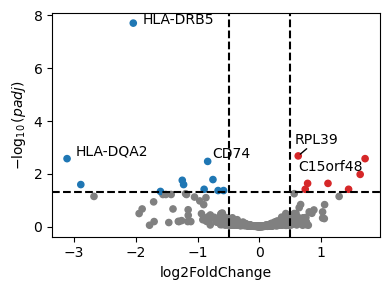

In [14]:
dc.pl.volcano(DEG_output['Macrophages'], x="log2FoldChange", y="padj")

## Enrichment Analysis

In [15]:
DEG_output.keys()

dict_keys(['Secretory', 'Multiciliated', 'Suprabasal', 'Basal', 'Squamous', 'Macrophages'])

In [16]:
DEG_output_wide = {}

for k, v in DEG_output.items():
    temp_res_df = DEG_output[k]
    temp_res_df = temp_res_df.loc[~temp_res_df['stat'].isna(), :]
    DEG_output_wide[k] = temp_res_df[['stat']].T.rename(index={'stat': 'dz.vs.nl'})

In [17]:
DEG_output['Macrophages']

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,idx
A2ML1,0.027651,0.882691,3.138568,0.281240,0.778526,NaN,A2ML1
A4GALT,0.654036,-1.778356,1.373372,-1.294883,0.195361,NaN,A4GALT
AAAS,0.382179,-0.754634,1.561408,-0.483303,0.628880,NaN,AAAS
AACS,0.054172,0.929045,3.138926,0.295976,0.767249,NaN,AACS
AAGAB,0.615066,-1.224273,1.193977,-1.025374,0.305187,NaN,AAGAB
...,...,...,...,...,...,...,...
ZWINT,0.060419,1.889282,3.142795,0.601147,0.547742,NaN,ZWINT
ZXDC,0.842433,0.038055,1.100591,0.034577,0.972417,NaN,ZXDC
ZYG11B,0.508468,-0.043752,1.246493,-0.035100,0.972000,NaN,ZYG11B
ZYX,10.367921,-0.102114,0.337689,-0.302390,0.762354,0.942217,ZYX


In [18]:
DEG_output_wide['Macrophages']

,A2ML1,A4GALT,AAAS,AACS,AAGAB,AAK1,AAMDC,AAMP,AAR2,AARS,...,ZSWIM8,ZSWIM9,ZUP1,ZW10,ZWILCH,ZWINT,ZXDC,ZYG11B,ZYX,ZZEF1
dz.vs.nl,0.28124,-1.294883,-0.483303,0.295976,-1.025374,-0.903349,-0.742247,-1.006375,0.832155,-0.701555,...,-0.191225,0.62916,0.565395,0.747193,-0.270346,0.601147,0.034577,-0.0351,-0.30239,-0.348157


In [19]:
hallmark = dc.op.hallmark(organism="human")
hallmark

,source,target
0,IL2_STAT5_SIGNALING,MAFF
1,COAGULATION,MAFF
2,HYPOXIA,MAFF
3,TNFA_SIGNALING_VIA_NFKB,MAFF
4,COMPLEMENT,MAFF
...,...,...
7313,PANCREAS_BETA_CELLS,STXBP1
7314,PANCREAS_BETA_CELLS,ELP4
7315,PANCREAS_BETA_CELLS,GCG
7316,PANCREAS_BETA_CELLS,PCSK2


In [20]:
list(hallmark['source'].unique())

['IL2_STAT5_SIGNALING',
 'COAGULATION',
 'HYPOXIA',
 'TNFA_SIGNALING_VIA_NFKB',
 'COMPLEMENT',
 'P53_PATHWAY',
 'GLYCOLYSIS',
 'APOPTOSIS',
 'EPITHELIAL_MESENCHYMAL_TRANSITION',
 'PROTEIN_SECRETION',
 'ADIPOGENESIS',
 'BILE_ACID_METABOLISM',
 'INFLAMMATORY_RESPONSE',
 'UNFOLDED_PROTEIN_RESPONSE',
 'TGF_BETA_SIGNALING',
 'KRAS_SIGNALING_UP',
 'UV_RESPONSE_UP',
 'ALLOGRAFT_REJECTION',
 'INTERFERON_GAMMA_RESPONSE',
 'INTERFERON_ALPHA_RESPONSE',
 'IL6_JAK_STAT3_SIGNALING',
 'XENOBIOTIC_METABOLISM',
 'ESTROGEN_RESPONSE_LATE',
 'KRAS_SIGNALING_DN',
 'MYC_TARGETS_V2',
 'WNT_BETA_CATENIN_SIGNALING',
 'NOTCH_SIGNALING',
 'CHOLESTEROL_HOMEOSTASIS',
 'ANGIOGENESIS',
 'HEDGEHOG_SIGNALING',
 'MYOGENESIS',
 'APICAL_JUNCTION',
 'G2M_CHECKPOINT',
 'ANDROGEN_RESPONSE',
 'UV_RESPONSE_DN',
 'MYC_TARGETS_V1',
 'E2F_TARGETS',
 'ESTROGEN_RESPONSE_EARLY',
 'MTORC1_SIGNALING',
 'HEME_METABOLISM',
 'PI3K_AKT_MTOR_SIGNALING',
 'FATTY_ACID_METABOLISM',
 'MITOTIC_SPINDLE',
 'APICAL_SURFACE',
 'REACTIVE_OXYGEN_SPE

In [ ]:
nrows = 2
ncols = 3

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, sharex=True,
                        figsize=(20,12)
                       )
flat_axes = axs.flatten()

for (cell_type, data_df), ax in zip(DEG_output_wide.items(), flat_axes):
    hm_acts, hm_padj = dc.mt.ulm(data=data_df, net=hallmark)
    msk = (hm_padj.T < 0.05).iloc[:, 0]
    hm_acts = hm_acts.loc[:, msk]
    
    dc.pl.barplot(data=hm_acts, name='dz.vs.nl',
                  vmin=-10, vmax=10,
                  ax=ax)
    ax.set_title(cell_type)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
plt.tight_layout()    
    
plt.savefig(f'{OUTPUT_DIR}/cfhv_fig4c_new_revised.png', dpi=300)
plt.savefig(f'{OUTPUT_DIR}/cfhv_fig4c_new_revised.svg')
plt.show()

## Leading Edge Analysis

leading edge: ['EGR1' 'NINJ1' 'FOS' 'NR4A1' 'PPP1R15A']


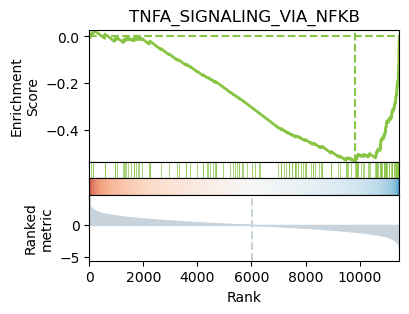

In [31]:
_, le = dc.pl.leading_edge(
    DEG_output['Secretory'],
    stat="stat",
    net=hallmark,
    name="TNFA_SIGNALING_VIA_NFKB"
)

print("leading edge:", le[:5])

leading edge: ['FOS' 'MAP3K8' 'SDC4' 'FOSB' 'RHOB']


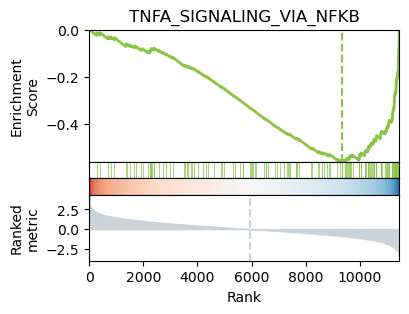

In [32]:
_, le = dc.pl.leading_edge(
    DEG_output['Suprabasal'],
    stat="stat",
    net=hallmark,
    name="TNFA_SIGNALING_VIA_NFKB"
)

print("leading edge:", le[:5])

leading edge: ['NR4A2' 'AREG' 'CCL5' 'NR4A1' 'CLCF1']


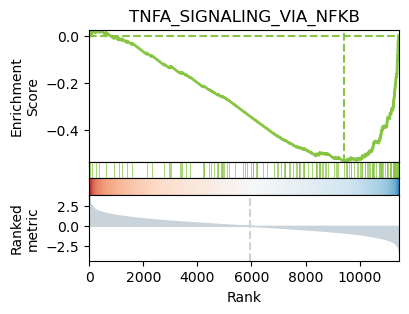

In [33]:
_, le = dc.pl.leading_edge(
    DEG_output['Basal'],
    stat="stat",
    net=hallmark,
    name="TNFA_SIGNALING_VIA_NFKB"
)

print("leading edge:", le[:5])

leading edge: ['FOSL1' 'CDKN1A' 'EIF1' 'IER5' 'ATF3']


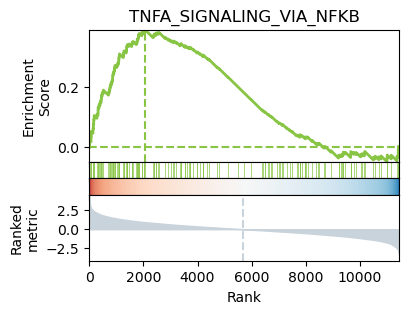

In [34]:
_, le = dc.pl.leading_edge(
    DEG_output['Squamous'],
    stat="stat",
    net=hallmark,
    name="TNFA_SIGNALING_VIA_NFKB"
)

print("leading edge:", le[:5])

leading edge: ['CALR' 'LSM4' 'FUS' 'EDEM1' 'EIF4G1']


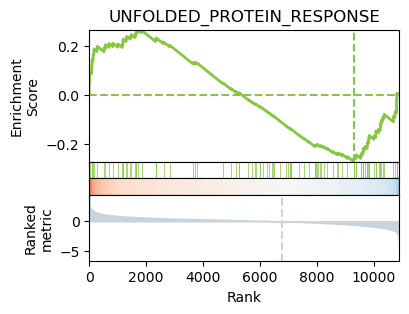

In [35]:
_, le = dc.pl.leading_edge(
    DEG_output['Macrophages'],
    stat="stat",
    net=hallmark,
    name="UNFOLDED_PROTEIN_RESPONSE"
)

print("leading edge:", le[:5])

leading edge: ['CD74' 'PSMB8' 'B2M' 'STAT2' 'HLA-C']


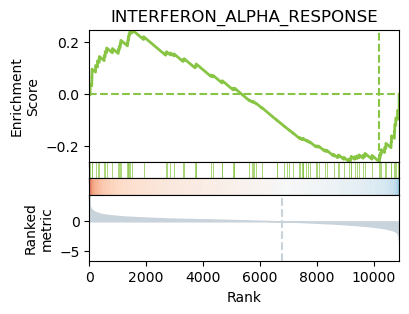

In [36]:
_, le = dc.pl.leading_edge(
    DEG_output['Macrophages'],
    stat="stat",
    net=hallmark,
    name="INTERFERON_ALPHA_RESPONSE"
)

print("leading edge:", le[:5])

## Double check using progeny

In [37]:
progeny = dc.op.progeny(organism="human")
progeny

,source,target,weight,padj
0,Androgen,TMPRSS2,11.490631,2.384806e-47
1,Androgen,NKX3-1,10.622551,2.205102e-44
2,Androgen,MBOAT2,10.472733,4.632376e-44
3,Androgen,KLK2,10.176186,1.944410e-40
4,Androgen,SARG,11.386852,2.790210e-40
...,...,...,...,...
62416,p53,ENPP2,2.771405,4.993215e-02
62417,p53,ARRDC4,3.494328,4.996747e-02
62418,p53,MYO1B,-1.148057,4.997905e-02
62419,p53,CTSC,-1.784693,4.998864e-02


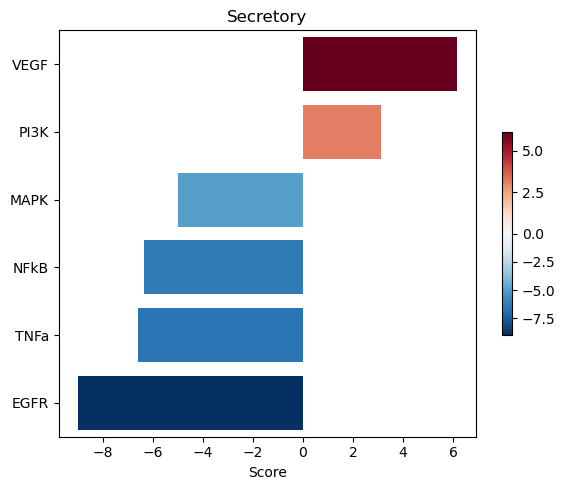

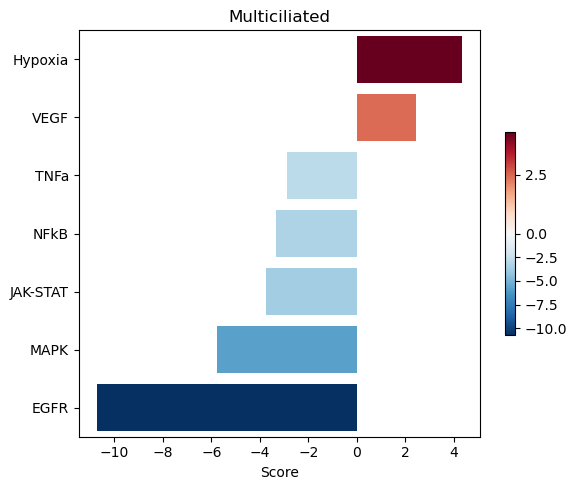

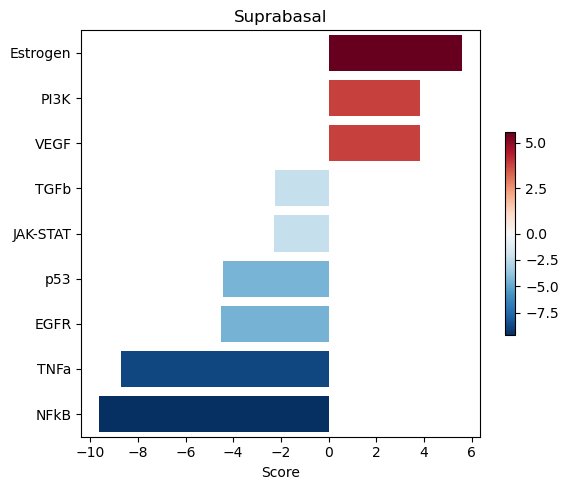

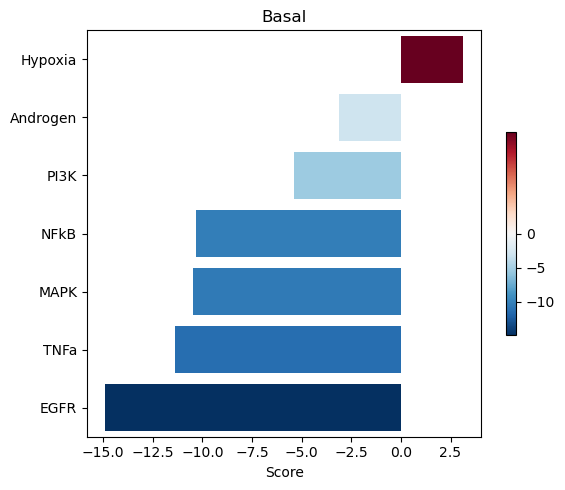

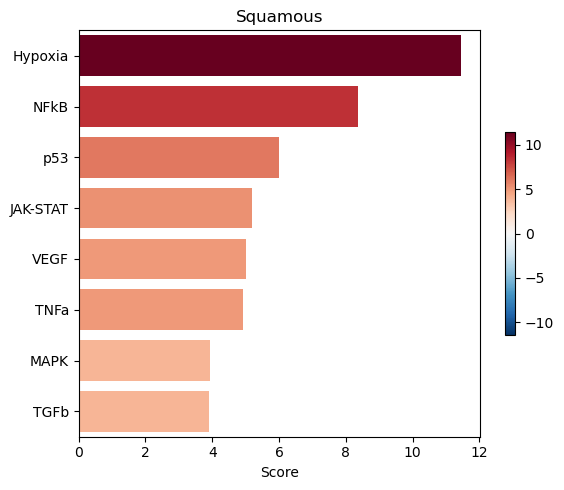

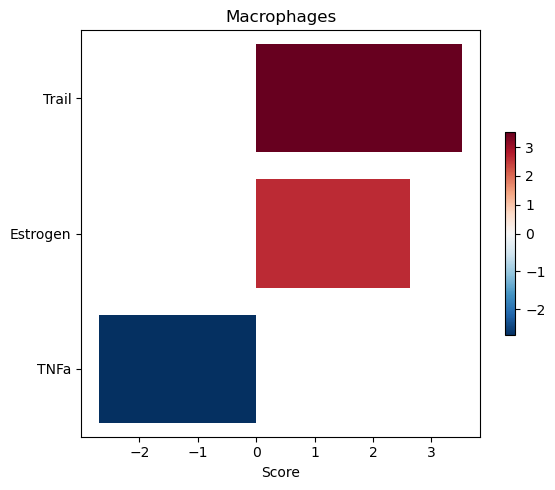

In [38]:
for k, v in DEG_output_wide.items():
    hm_acts, hm_padj = dc.mt.ulm(data=DEG_output_wide[k], net=progeny)
    msk = (hm_padj.T < 0.05).iloc[:, 0]
    hm_acts = hm_acts.loc[:, msk]
    
    dc.pl.barplot(data=hm_acts, name='dz.vs.nl', figsize=(6, 5))
    plt.title(k)
    plt.show()